# Evidence-unit and statistical-power audit

## tl;dr

The current 19,440-row hardware confirmation is complete and useful, but its
cross-placement sample size is **three per requested GPU**, not 3,240. The 30
timings in each cell stabilize a placement median; they do not create 30
independent hardware replicates.

All 18 manifests contain distinct GPU UUIDs. The principal remaining
heterogeneity is real provider placement variation, including both PCIe and
SXM A100s under one requested class. Current claims should therefore remain
descriptive and directional.

For the native-runtime confirmation, use a fresh staged design. Six placements
per card are exploratory only and 12 is an absolute floor. Freeze the
implementation and primary cells, then target **30 unique placements per
primary GPU class**, increasing that count if a blinded simulation using the
upper nuisance-variance bound requires it. At placement log-SD 0.22, 29
placements give approximately 90% power for the frozen 1.15× smallest
worthwhile speedup at one-sided alpha 0.025.

## Context & Methods

### Key assumptions

- The inferential unit for hardware generalization is a fresh physical
  GPU/host placement, identified by GPU UUID where exposed.
- Repeated timings within a placement estimate its stable summary and temporal
  noise. They are nested observations, not independent placements.
- Latency and speedup ratios are analyzed on the log scale.
- The power calculation is a sensitivity analysis for a paired one-sample
  log-ratio test. It is not a retrospective significance test of the pilot.
- Directional superiority decisions use one-sided alpha 0.025. The two primary
  hardware strata use a max-statistic bootstrap or Holm adjustment; secondary
  cells use simultaneous intervals or false-discovery-rate control and cannot
  become abstract claims.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import nct, t

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED = ROOT / "data/processed"
RAW = ROOT / "data/raw"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

placement = pd.read_csv(PROCESSED / "hardware-replication-placement-cost.csv")
quality = pd.read_csv(PROCESSED / "hardware-replication-run-quality.csv")
manifest_paths = sorted(RAW.glob("pilot-0??-modal-*-rep?-*.manifest.json"))
manifests = [json.loads(path.read_text()) for path in manifest_paths]

def first_gpu(record):
    rows = record.get("nvidia_smi") or []
    return rows[0] if rows else {}

manifest_frame = pd.DataFrame(
    {
        "requested_gpu": record.get("requested_gpu"),
        "placement_replicate": record.get("placement_replicate"),
        "gpu_uuid": first_gpu(record).get("uuid"),
        "physical_name": first_gpu(record).get("name"),
        "cpu_vendor": (record.get("cpu") or {}).get("vendor_id"),
        "cpu_family": (record.get("cpu") or {}).get("cpu_family"),
        "cpu_model": (record.get("cpu") or {}).get("model"),
    }
    for record in manifests
)
sns.set_theme(style="whitegrid", context="notebook")

## Data integrity and experimental grain

In [2]:
assert len(manifest_frame) == 18
assert manifest_frame["gpu_uuid"].notna().all()
assert manifest_frame["gpu_uuid"].nunique() == 18
assert len(quality) == 18
assert quality["rows"].sum() == 19_440
assert (quality["rows"] == 1_080).all()
assert (quality["execution_error_rows"] == 0).all()
assert (quality["duplicate_case_repetitions"] == 0).all()
assert (quality["invalid_shapes"] == 0).all()
assert placement["source_file"].nunique() == 18
assert placement.groupby("requested_gpu")["source_file"].nunique().eq(3).all()

pd.DataFrame(
    {
        "quantity": [
            "raw timing rows",
            "fresh placement ledgers",
            "unique GPU UUIDs",
            "placements per requested GPU",
            "timed repetitions per cell/placement",
            "execution errors",
            "invalid shapes",
        ],
        "value": [19_440, 18, 18, 3, 30, 0, 0],
        "inferential_role": [
            "nested timing observations",
            "cross-placement units",
            "independence evidence",
            "current per-class n",
            "median precision only",
            "quality check",
            "quality check",
        ],
    }
)

,quantity,value,inferential_role
0,raw timing rows,19440,nested timing observations
1,fresh placement ledgers,18,cross-placement units
2,unique GPU UUIDs,18,independence evidence
3,placements per requested GPU,3,current per-class n
4,timed repetitions per cell/placement,30,median precision only
5,execution errors,0,quality check
6,invalid shapes,0,quality check


In [3]:
manifest_frame.sort_values(["requested_gpu", "placement_replicate"])

,requested_gpu,placement_replicate,gpu_uuid,physical_name,cpu_vendor,cpu_family,cpu_model
6,A10,1,GPU-87a07b05-25c1-9215-14ea-aa088e76a03f,NVIDIA A10,GenuineIntel,6,106
7,A10,2,GPU-1085be7d-3334-54f8-f0f0-25f507cc6777,NVIDIA A10,GenuineIntel,6,106
8,A10,3,GPU-d7230c2e-7d1f-97d4-684c-76d060471d88,NVIDIA A10,GenuineIntel,6,106
12,A100-80GB,1,GPU-4e903331-3124-4621-667d-ae891950ce7d,NVIDIA A100-SXM4-80GB,AuthenticAMD,143,49
13,A100-80GB,2,GPU-6df21262-8b12-3982-46db-3743d0fabd51,NVIDIA A100 80GB PCIe,AuthenticAMD,175,1
14,A100-80GB,3,GPU-c3687a5a-a33b-7665-2f9c-65045ec21cb8,NVIDIA A100-SXM4-80GB,AuthenticAMD,143,49
15,H100!,1,GPU-36c1cf3d-7ede-c32b-6c79-c3e5136d85e1,NVIDIA H100 80GB HBM3,GenuineIntel,6,143
16,H100!,2,GPU-b1351d59-15fa-cf75-5e4f-2b10bdb5e808,NVIDIA H100 80GB HBM3,GenuineIntel,6,143
17,H100!,3,GPU-02a7981f-4a58-4956-9580-5b4b7434cc82,NVIDIA H100 80GB HBM3,GenuineIntel,6,143
3,L4,1,GPU-03ca0a72-ff18-75db-d687-1b64918a2763,NVIDIA L4,GenuineIntel,6,85


Every manifest has a distinct GPU UUID, supporting the intended fresh-placement
interpretation. Requested GPU class is not always a homogeneous physical SKU:
Modal returned both A100-SXM4-80GB and A100-80GB-PCIe. A class-level claim must
either include that deployment heterogeneity or restrict and name an exact SKU.

## Observed placement variation

In [4]:
primary_cells = placement[
    (
        (placement["observation_horizon"].eq(64))
        & (placement["agent_count"].isin([8, 256]))
    )
    | (
        placement["observation_horizon"].eq(1)
        & placement["agent_count"].eq(256)
    )
].copy()
primary_cells["log_speedup"] = np.log(primary_cells["speedup_vs_best_cpu"])
variation = (
    primary_cells.groupby(
        ["requested_gpu", "observation_horizon", "agent_count"],
        as_index=False,
    )
    .agg(
        placements=("source_file", "nunique"),
        geometric_mean_speedup=("log_speedup", lambda values: np.exp(values.mean())),
        placement_log_sd=("log_speedup", "std"),
        speedup_min=("speedup_vs_best_cpu", "min"),
        speedup_max=("speedup_vs_best_cpu", "max"),
    )
)
variation.sort_values(
    ["observation_horizon", "agent_count", "requested_gpu"]
)

,requested_gpu,observation_horizon,agent_count,placements,geometric_mean_speedup,placement_log_sd,speedup_min,speedup_max
0,A10,1,256,3,1.035240,0.003436,1.031406,1.038424
3,A100-80GB,1,256,3,0.905936,0.046897,0.860480,0.943184
6,H100!,1,256,3,0.907506,0.053050,0.854430,0.944201
9,L4,1,256,3,1.161085,0.010690,1.147780,1.172272
12,L40S,1,256,3,0.904535,0.070109,0.842516,0.969298
15,T4,1,256,3,1.183253,0.041826,1.128772,1.222557
1,A10,64,8,3,2.472314,0.111896,2.200506,2.750647
4,A100-80GB,64,8,3,1.830088,0.294690,1.392065,2.500255
7,H100!,64,8,3,2.234309,0.241901,1.733217,2.805663
10,L4,64,8,3,2.412848,0.070579,2.244986,2.585065


The observed log-SD ranges from extremely small to about 0.31 in these selected
cells. With only three placements, each SD is itself uncertain and cannot be
used as a precise plug-in estimate. The confirmatory sample size therefore uses
a conservative sensitivity grid and must be recalculated from an exploratory
pilot without reusing pilot outcomes as confirmation.

## Power sensitivity

In [5]:
ONE_SIDED_ALPHA = 0.025
TARGET_POWER = 0.90

def one_sided_log_ratio_power(n, true_ratio, log_sd, alpha=ONE_SIDED_ALPHA):
    degrees_freedom = n - 1
    critical_value = t.ppf(1 - alpha, degrees_freedom)
    noncentrality = np.sqrt(n) * np.log(true_ratio) / log_sd
    return 1 - nct.cdf(critical_value, degrees_freedom, noncentrality)

records = []
for log_sd in [0.05, 0.10, 0.15, 0.20, 0.22, 0.25, 0.30]:
    for true_ratio in [1.10, 1.15, 1.20, 1.25, 1.30]:
        required = next(
            (
                n
                for n in range(3, 101)
                if one_sided_log_ratio_power(n, true_ratio, log_sd) >= TARGET_POWER
            ),
            None,
        )
        records.append(
            {
                "placement_log_sd": log_sd,
                "true_speedup": true_ratio,
                "placements_for_90pct_power": required,
                "power_at_n12": one_sided_log_ratio_power(12, true_ratio, log_sd),
                "power_at_n30": one_sided_log_ratio_power(30, true_ratio, log_sd),
            }
        )
power_table = pd.DataFrame(records)
power_table[power_table["true_speedup"].isin([1.15, 1.20])].round(3)

,placement_log_sd,true_speedup,placements_for_90pct_power,power_at_n12,power_at_n30
1,0.05,1.15,4.0,1.000,1.000
2,0.05,1.20,4.0,1.000,1.000
6,0.10,1.15,8.0,0.992,1.000
7,0.10,1.20,6.0,1.000,1.000
11,0.15,1.15,15.0,0.836,0.999
12,0.15,1.20,10.0,0.969,1.000
16,0.20,1.15,24.0,0.597,0.959
17,0.20,1.20,15.0,0.819,0.998
21,0.22,1.15,29.0,0.519,0.920
22,0.22,1.20,18.0,0.743,0.992


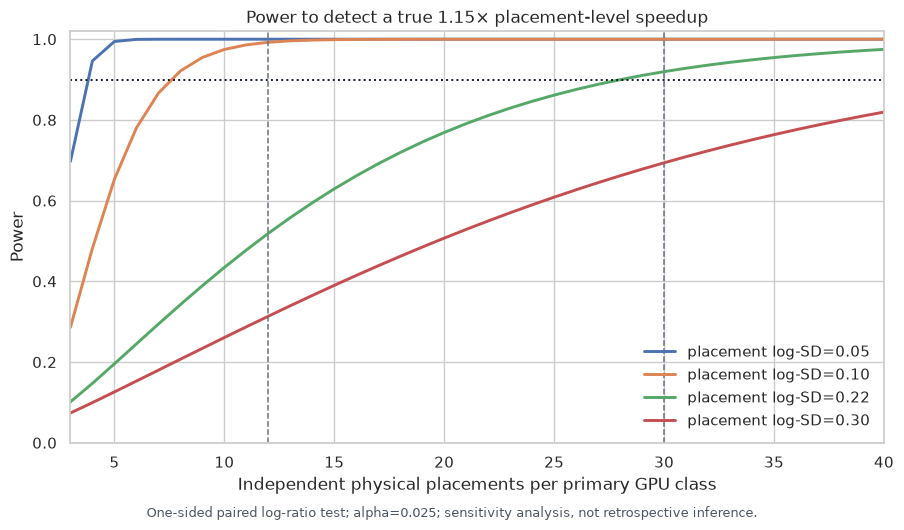

In [6]:
sample_sizes = np.arange(3, 41)
fig, axis = plt.subplots(figsize=(9.2, 5.2))
for log_sd in [0.05, 0.10, 0.22, 0.30]:
    axis.plot(
        sample_sizes,
        [one_sided_log_ratio_power(n, 1.15, log_sd) for n in sample_sizes],
        linewidth=2.1,
        label=f"placement log-SD={log_sd:.2f}",
    )
axis.axhline(TARGET_POWER, color="#111827", linestyle=":", linewidth=1.4)
axis.axvline(12, color="#6B7280", linestyle="--", linewidth=1.1)
axis.axvline(30, color="#6B7280", linestyle="--", linewidth=1.1)
axis.set_ylim(0, 1.02)
axis.set_xlim(3, 40)
axis.set_xlabel("Independent physical placements per primary GPU class")
axis.set_ylabel("Power")
axis.set_title("Power to detect a true 1.15× placement-level speedup")
axis.legend(frameon=False, loc="lower right")
fig.text(
    0.5,
    -0.01,
    "One-sided paired log-ratio test; alpha=0.025; sensitivity analysis, not retrospective inference.",
    ha="center",
    fontsize=9,
    color="#4B5563",
)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"statistical-power-sensitivity.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

At placement log-SD 0.22, approximately 29 placements are required for 90%
power at the frozen 1.15× smallest worthwhile effect. This motivates the
30-placement default. The count must be increased when the blinded upper
nuisance-variance bound is worse; it must not be reduced merely because an
interim point estimate looks favorable. Detecting a 1.10× effect under high
placement variation would require far more placements and is not the frozen
systems claim.

## Confirmatory design decision

In [7]:
pd.DataFrame(
    [
        {
            "study": "native ready-cohort runtime",
            "exploratory_units": "6 fresh placements / selected GPU",
            "confirmatory_units": "30 unique placements by default; >=12 floor; increase by blinded power simulation",
            "primary_analysis": "paired placement log-ratio; hierarchical placement bootstrap",
            "primary_guardrail": "exact per-transition trajectory equality",
        },
        {
            "study": "shared-GPU slack harvesting",
            "exploratory_units": "4 fresh placements / GPU-load regime",
            "confirmatory_units": "30--80 unique placements by blinded P99-variance simulation; >=20 floor",
            "primary_analysis": "benefit superiority plus TTFT/TPOT P99 noninferiority",
            "primary_guardrail": "one-sided upper CI below frozen SLO-degradation margin",
        },
        {
            "study": "diversity-regularity frontier",
            "exploratory_units": "discovery queries and model subsets",
            "confirmatory_units": "untouched queries/tasks plus independent serving placements",
            "primary_analysis": "paired query bootstrap/McNemar plus placement-level systems CI",
            "primary_guardrail": "subset selection never sees confirmatory outcomes",
        },
    ]
)

,study,exploratory_units,confirmatory_units,primary_analysis,primary_guardrail
0,native ready-cohort runtime,6 fresh placements / selected GPU,30 unique placements by default; >=12 floor; i...,paired placement log-ratio; hierarchical place...,exact per-transition trajectory equality
1,shared-GPU slack harvesting,4 fresh placements / GPU-load regime,30--80 unique placements by blinded P99-varian...,benefit superiority plus TTFT/TPOT P99 noninfe...,one-sided upper CI below frozen SLO-degradatio...
2,diversity-regularity frontier,discovery queries and model subsets,untouched queries/tasks plus independent servi...,paired query bootstrap/McNemar plus placement-...,subset selection never sees confirmatory outcomes


## Takeaways

1. Do not report a p-value based on 30 timing repetitions or pool the six GPU
   classes to manufacture an `n=18` homogeneous effect.
2. Current three-placement results support direction and effect-size ranges,
   not a universal hardware-population hypothesis test.
3. Choose a smallest effect of practical interest before confirmation. For the
   main runtime, the frozen default is 1.15×; a statistically detectable 1.03×
   speedup is not a systems contribution worth scaling.
4. Use fresh GPU UUIDs, randomized paired method blocks, placement-clustered
   intervals, complete failure ledgers, and exact semantic checks.
5. Treat latency benefit and SLO/utility safety as a joint claim: superiority
   on the benefit metric and noninferiority on every frozen guardrail.
6. Unlimited compute permits narrow confidence intervals; it never licenses
   optional stopping, post-hoc cells, or request-level pseudo-replication.